In [1]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile
import os

zip_file_path = "/content/drive/MyDrive/breast_cancer_dataset.zip"
extract_dir = "/content"

if os.path.exists(zip_file_path):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            # Extract all contents to the specified directory
            zip_ref.extractall(extract_dir)
        print(f"Successfully extracted '{zip_file_path}' to '{extract_dir}'")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is not a valid zip file.")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print(f"Error: '{zip_file_path}' does not exist.")

Mounted at /content/drive
Successfully extracted '/content/drive/MyDrive/breast_cancer_dataset.zip' to '/content'


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

In [3]:
train_dir = '/content/breast_cancer_dataset/train'
val_dir = '/content/breast_cancer_dataset/validation'
test_dir = '/content/breast_cancer_dataset/test'

In [4]:
classes = os.listdir(train_dir)
num_classes = len(classes)
print(f'Number of Classes: {num_classes}')
print(f'Classes: {classes}')

Number of Classes: 2
Classes: ['Benign', 'Malignant']


In [5]:
plt.figure(figsize=(12, 10))
class_path = os.path.join(train_dir, classes[0])
img_names = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
# Iterate only up to the number of available images
for i in range(min(5, len(img_names))):
  img_name = img_names[i]
  img_path = os.path.join(class_path, img_name)
  img = plt.imread(img_path)

  plt.subplot(1, min(5, len(img_names)), i+1)
  plt.imshow(img)
  plt.title(f'{classes[0]} \n shape: {img.shape}')
  plt.axis('off')
plt.show()

<Figure size 1200x1000 with 0 Axes>

In [6]:
plt.figure(figsize=(12, 10))
class_path = os.path.join(train_dir, classes[1])
img_names = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
# Iterate only up to the number of available images
for i in range(min(5, len(img_names))):
  img_name = img_names[i]
  img_path = os.path.join(class_path, img_name)
  img = plt.imread(img_path)

  plt.subplot(1, min(5, len(img_names)), i+1)
  plt.imshow(img)
  plt.title(f'{classes[1]} \n shape: {img.shape}')
  plt.axis('off')
plt.show()

<Figure size 1200x1000 with 0 Axes>

In [7]:

img_width, img_height = 150, 150
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    class_mode = 'binary',
    shuffle = True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    class_mode = 'binary',
    shuffle = True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    class_mode = 'binary',
    shuffle = True
)

Found 2000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [8]:
class_mapping = train_generator.class_indices
print(class_mapping)
class_names = list(class_mapping.keys())
print("Class Names:", class_names)

{'Benign': 0, 'Malignant': 1}
Class Names: ['Benign', 'Malignant']


In [16]:
model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
]
)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,811,969 (25.99 MB)

 Trainable params: 6,811,969 (25.99 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    train_generator,
    steps_per_epoch = train_generator.samples // batch_size,
    epochs = 20,
    validation_data = val_generator,
    validation_steps = val_generator.samples // batch_size
)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9727 - loss: 0.0907 - val_accuracy: 0.9980 - val_loss: 0.0135
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 1.0000 - loss: 0.0161 - val_accuracy: 0.9965 - val_loss: 0.0152
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9938 - loss: 0.0166 - val_accuracy: 1.0000 - val_loss: 9.0396e-04
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 8.8520e-04
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 0.9990 - val_loss: 0.0037
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9990 - val_loss: 0.0040
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9960 - loss: 0.0143 - val_accuracy: 0.9985 - val_loss: 0.0044
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.

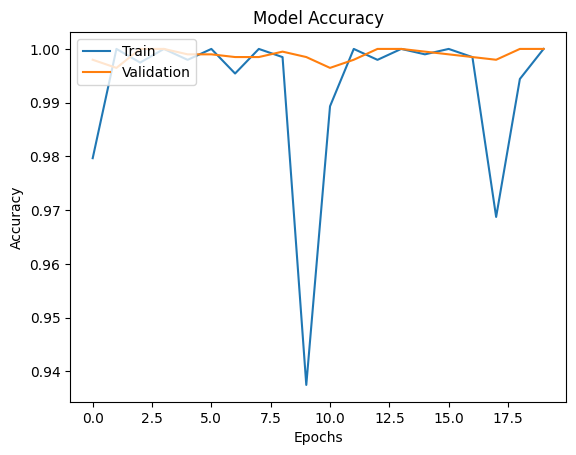

In [25]:
# Evaluate the model
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

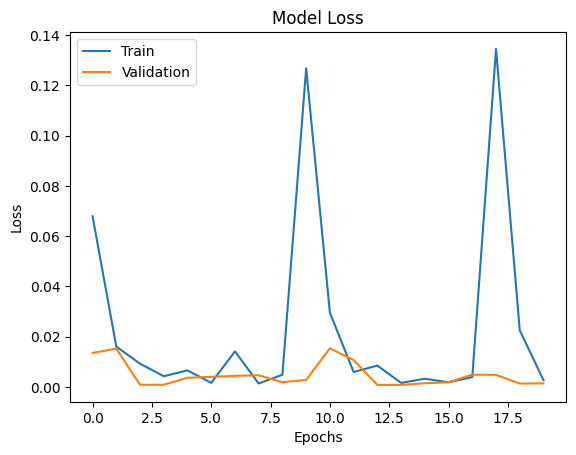

In [26]:
# Evaluate the model - plotting training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [27]:
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print(f'Test Accuracy: {test_acc:.4f}')

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 1.0000 - loss: 0.0013
Test Accuracy: 1.0000


In [28]:
model.save('FFD.keras')

In [29]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load
model = load_model('FFD.keras')

# Predict on new image
def predict(img_path):
  img = image.load_img(img_path, target_size=(150, 150))
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array /= 255.0

  prediction = model.predict(img_array)
  if prediction[0] > 0.5:
    predicted_class = class_names[1]
  else:
    predicted_class = class_names[0]

  plt.imshow(img)
  plt.title(f'Predicted: {predicted_class}')
  plt.axis('off')
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step


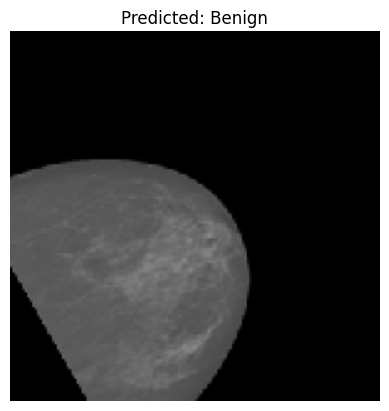

In [30]:
predict('/content/breast_cancer_dataset/test/Benign/BreastCancer_Benign/20586908 (10).png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


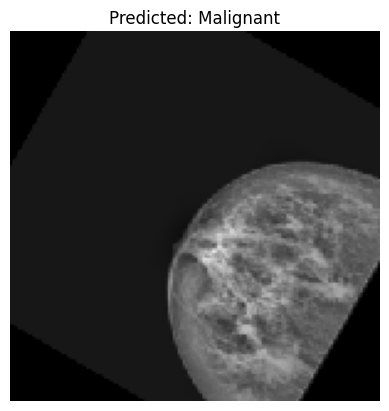

In [31]:
predict('/content/breast_cancer_dataset/test/Malignant/BreastCancer_Maglinant/20586934 (11).png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


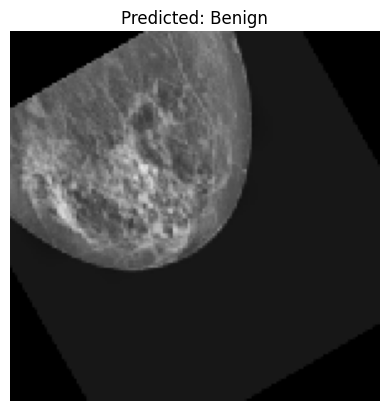

In [32]:
predict('/content/breast_cancer_dataset/validation/Benign/BreastCancer_Benign/20586908 (15).png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


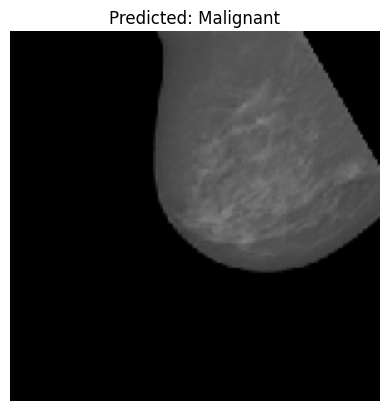

In [33]:
predict('/content/breast_cancer_dataset/test/Malignant/BreastCancer_Maglinant/20586986 (47).png')

In [ ]:
!pip install streamlit tensorflow pillow --quiet
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

from google.colab import drive
drive.mount('/content/drive')

app_code = """
import streamlit as st
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model

# Paths
MODEL_PATH = "/content/FFD.keras"
IMG_SIZE = (150, 150)

# Load model once
@st.cache_resource
def load_cnn_model():
    return load_model(MODEL_PATH)

model = load_cnn_model()

st.title("Breast Cancer Image Classifier")
st.write("Upload an image to predict if it is **Benign** or **Malignant**.")

uploaded_file = st.file_uploader("Choose an image", type=["jpg", "jpeg", "png"])

if uploaded_file:
    img = Image.open(uploaded_file).convert("RGB")
    st.image(img, caption="Uploaded Image", use_column_width=True)

    # Preprocess
    img_resized = img.resize(IMG_SIZE)
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    pred = model.predict(img_array)[0][0]
    label_pred = "Malignant" if pred > 0.5 else "Benign"
    st.markdown(f"### Prediction: **{label_pred}**")
    st.write(f"Confidence Score: `{pred:.4f}`")
"""

with open("app.py", "w") as f:
    f.write(app_code)

!streamlit run app.py --server.port 8501 &>/dev/null &

!cloudflared tunnel --url http://localhost:8501 --no-autoupdate

(Reading database ... 126288 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2025.8.0) over (2025.8.0) ...
Setting up cloudflared (2025.8.0) ...
Processing triggers for man-db (2.10.2-1) ...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2025-08-11T17:52:15Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-08